# 04 - Leaky VS Correct, Side By Side

This notebook doesn't run any new experiments - it just loads the two
CSVs saved by notebooks 02 and 03 and compares them directly. Run 02 and
03 at least once before this one.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

leaky = pd.read_csv("../results/tables/leaky_summary.csv")
correct = pd.read_csv("../results/tables/correct_summary.csv")

comparison = leaky.merge(correct, on=["split", "model"], suffixes=("_leaky", "_correct"),)
comparison

,split,model,mean_accuracy_leaky,max_accuracy_leaky,min_accuracy_leaky,mean_accuracy_correct,max_accuracy_correct,min_accuracy_correct
0,50-50,Random Forest,0.980457,0.992970,0.957821,0.958386,0.985965,0.926316
1,50-50,Decision Tree,0.966081,0.985940,0.936731,0.928175,0.954386,0.891228
2,50-50,Logistic Regression,0.956591,0.975395,0.940246,0.949860,0.975439,0.919298
3,50-50,Neural Network,0.941424,0.966608,0.913884,0.935228,0.978947,0.887719
4,50-50,Naive Bayes,0.939543,0.954306,0.908612,0.938982,0.961404,0.912281
5,50-50,Nearest Neighbor,0.934394,0.954306,0.901582,0.924000,0.950877,0.870175
6,50-50,SVM,0.919033,0.934974,0.898067,0.916351,0.943860,0.880702
7,60-40,Random Forest,0.985614,1.000000,0.956140,0.959605,0.986842,0.925439
8,60-40,Decision Tree,0.972807,0.991228,0.947368,0.931491,0.978070,0.885965
9,60-40,Logistic Regression,0.957500,0.978070,0.938596,0.950132,0.973684,0.912281


## Save The Merged Comparison Table

In [2]:
comparison.to_csv("../results/tables/leaky_vs_correct_comparison.csv", index=False)
print("saved to results/tables/leaky_vs_correct_comparison.csv")

saved to results/tables/leaky_vs_correct_comparison.csv


## Best-Case (Max) Accuracy: leaky VS correct

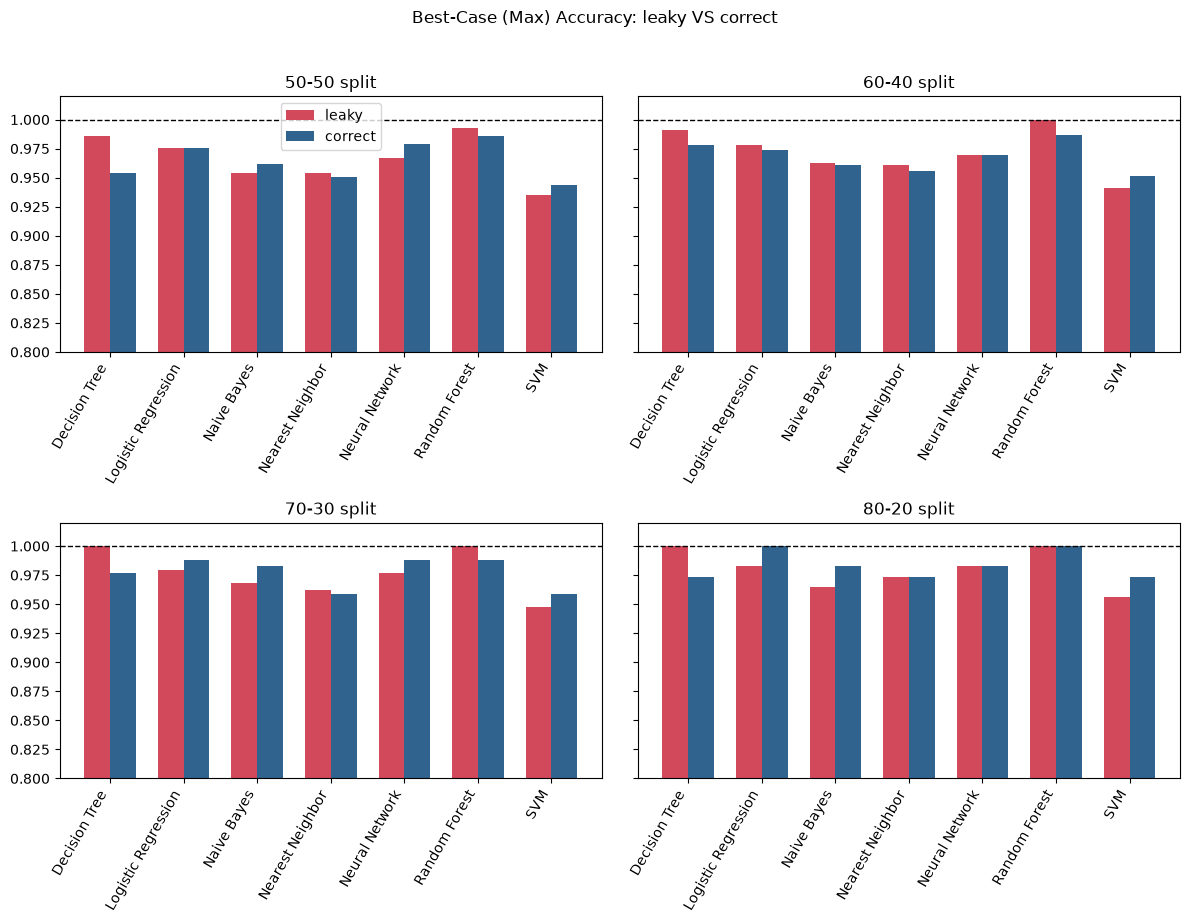

In [3]:
SPLIT_RATIOS = ["50-50", "60-40", "70-30", "80-20"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)

for ax, split_name in zip(axes.flat, SPLIT_RATIOS):
    subset = comparison[comparison["split"] == split_name].sort_values("model")
    x = range(len(subset))
    width = 0.35

    ax.bar([i - width / 2 for i in x], subset["max_accuracy_leaky"], width, label="leaky", color="#D1495B")
    ax.bar([i + width / 2 for i in x], subset["max_accuracy_correct"], width, label="correct", color="#30638E")
    ax.axhline(1.0, color="black", linestyle="--", linewidth=1)

    ax.set_xticks(list(x))
    ax.set_xticklabels(subset["model"], rotation=60, ha="right")
    ax.set_title(f"{split_name} split")
    ax.set_ylim(0.8, 1.02)

axes[0, 0].legend()
fig.suptitle("Best-Case (Max) Accuracy: leaky VS correct", y=1.02)
fig.tight_layout()
fig.savefig("../results/figures/04_max_accuracy_leaky_vs_correct.png", dpi=150, bbox_inches="tight")
plt.show()

## Worst-Case (Min) Accuracy: leaky VS correct
This is the number the paper argues actually matters for a disease-diagnosis model.

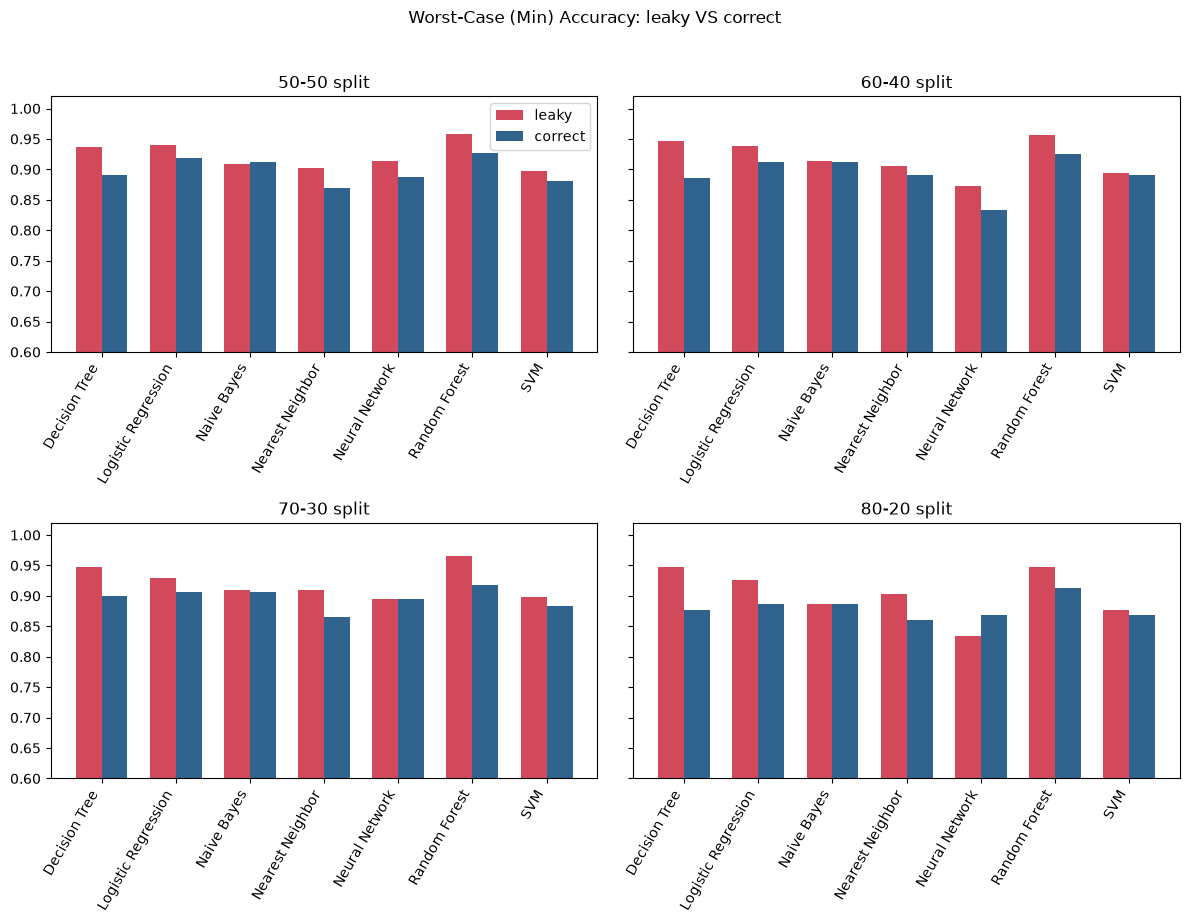

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)

for ax, split_name in zip(axes.flat, SPLIT_RATIOS):
    subset = comparison[comparison["split"] == split_name].sort_values("model")
    x = range(len(subset))
    width = 0.35

    ax.bar([i - width / 2 for i in x], subset["min_accuracy_leaky"], width, label="leaky", color="#D1495B")
    ax.bar([i + width / 2 for i in x], subset["min_accuracy_correct"], width, label="correct", color="#30638E")

    ax.set_xticks(list(x))
    ax.set_xticklabels(subset["model"], rotation=60, ha="right")
    ax.set_title(f"{split_name} split")
    ax.set_ylim(0.6, 1.02)

axes[0, 0].legend()
fig.suptitle("Worst-Case (Min) Accuracy: leaky VS correct", y=1.02)
fig.tight_layout()
fig.savefig("../results/figures/04_min_accuracy_leaky_vs_correct.png", dpi=150, bbox_inches="tight")
plt.show()